# 02 — Map Factors
Analyses map pool, score margins, CT advantage, overtime, and pick/ban dynamics.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from eda.utils import load_tables, enrich_matches, get_working_matches, get_completed_maps, savefig

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)
comp_maps = get_completed_maps(tables['maps'], working)


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/02_map_pickrate.png


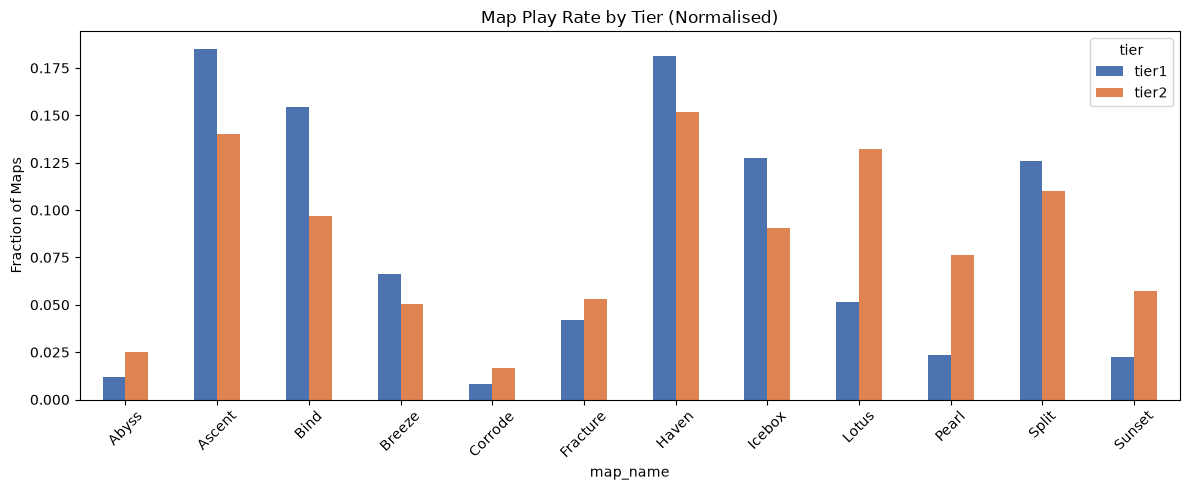

In [2]:
# 2a. Map pick frequency (normalised per tier)
map_freq = comp_maps.groupby(['tier','map_name']).size().unstack(fill_value=0)
map_freq_norm = map_freq.div(map_freq.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12,5))
map_freq_norm.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Map Play Rate by Tier (Normalised)')
ax.set_ylabel('Fraction of Maps')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig(fig, '02_map_pickrate')
plt.show()


Map score margin — T1 median: 5.0, T2 median: 5.0
Mann-Whitney U: stat=170407271, p=0.0000
Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/02_score_margin.png


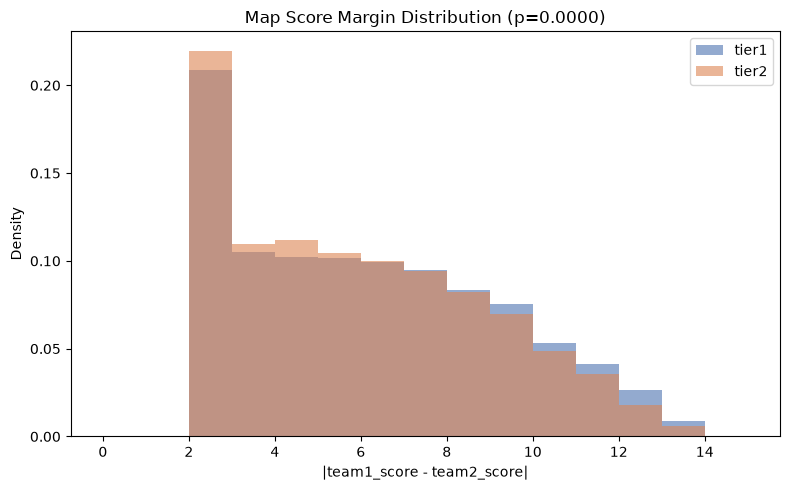

In [3]:
# 2b. Map score margin distribution (Mann-Whitney U test)
comp_maps['margin'] = abs(comp_maps['team1_score'].fillna(0) - comp_maps['team2_score'].fillna(0))
t1_margins = comp_maps[comp_maps['tier']=='tier1']['margin'].dropna()
t2_margins = comp_maps[comp_maps['tier']=='tier2']['margin'].dropna()
stat, p = mannwhitneyu(t1_margins, t2_margins, alternative='two-sided')
print(f"Map score margin — T1 median: {t1_margins.median():.1f}, T2 median: {t2_margins.median():.1f}")
print(f"Mann-Whitney U: stat={stat:.0f}, p={p:.4f}")

fig, ax = plt.subplots(figsize=(8,5))
for tier, color in [('tier1','#4C72B0'),('tier2','#DD8452')]:
    data = comp_maps[comp_maps['tier']==tier]['margin'].dropna()
    ax.hist(data, bins=range(0,16), alpha=0.6, color=color, label=tier, density=True)
ax.set_title(f'Map Score Margin Distribution (p={p:.4f})')
ax.set_xlabel('|team1_score - team2_score|')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
savefig(fig, '02_score_margin')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/02_ct_heatmap.png


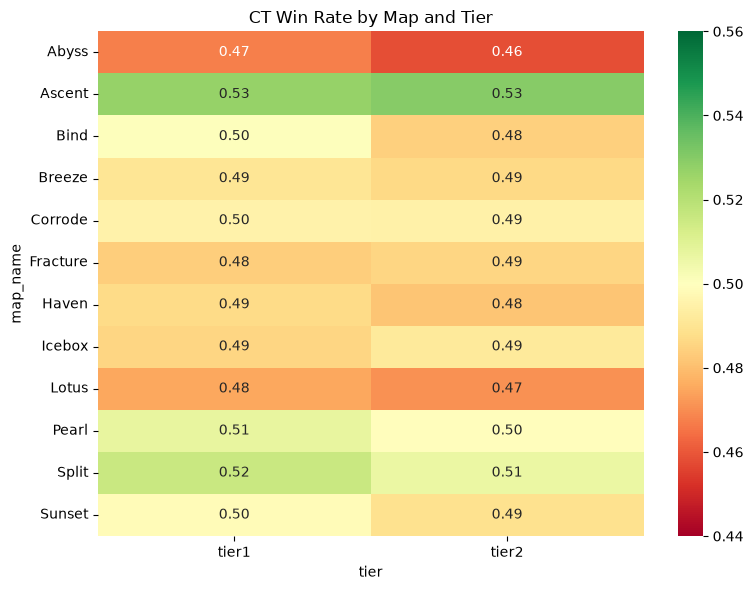

In [4]:
# 2c. CT win rate per map × tier (heatmap)
# Use map_rounds: rounds where winning_side=='ct' per (map_id, tier)
rounds = tables['map_rounds']
rounds_t = rounds.merge(
    comp_maps[['map_id','map_name','tier']], on='map_id', how='inner'
)
ct_by_map_tier = (rounds_t.groupby(['map_name','tier'])['winning_side']
                  .apply(lambda s: (s=='ct').mean())
                  .unstack())
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(ct_by_map_tier, annot=True, fmt='.2f', center=0.5,
            cmap='RdYlGn', vmin=0.44, vmax=0.56, ax=ax)
ax.set_title('CT Win Rate by Map and Tier')
plt.tight_layout()
savefig(fig, '02_ct_heatmap')
plt.show()


OT rate by tier:
tier
tier1    0.076566
tier2    0.080476
Name: went_to_ot, dtype: float64
Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/02_ot_rate.png


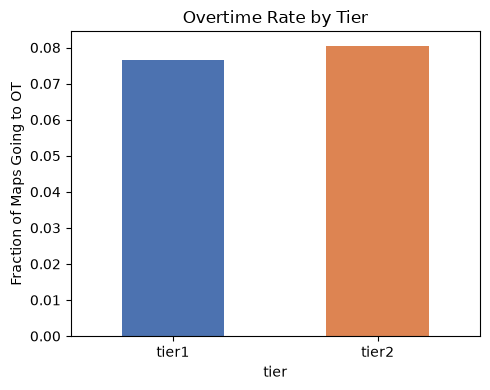

In [5]:
# 2d. Overtime rate by tier
comp_maps['went_to_ot'] = (
    comp_maps['team1_score_ot'].notna() &
    (comp_maps['team1_score_ot'].fillna(0).astype(int) > 0)
)
ot_rate = comp_maps.groupby('tier')['went_to_ot'].mean()
print("OT rate by tier:")
print(ot_rate)
fig, ax = plt.subplots(figsize=(5,4))
ot_rate.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Overtime Rate by Tier')
ax.set_ylabel('Fraction of Maps Going to OT')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
savefig(fig, '02_ot_rate')
plt.show()


In [6]:
# 2e. Pick-map vs. decider win rate (from map_vetos join)
vetos = tables['map_vetos'].merge(working[['match_id','tier']], on='match_id', how='inner')
picks = vetos[vetos['action']=='pick'][['match_id','map_name','team_id','tier']].rename(
    columns={'team_id':'picking_team_id'})
# Join picks to comp_maps on match_id + map_name
pick_maps = comp_maps.merge(picks, on=['match_id','map_name'], how='left', suffixes=('','_veto'))
# Ensure tier column from veto doesn't clash
if 'tier_veto' in pick_maps.columns:
    pick_maps = pick_maps.drop(columns=['tier_veto'])
pick_maps['pick_type'] = pick_maps.apply(
    lambda r: 'decider' if r['is_decider']
              else ('picked' if pd.notna(r.get('picking_team_id')) else 'unknown'),
    axis=1
)
pick_maps['picking_team_won'] = (pick_maps['map_winner_id'] == pick_maps.get('picking_team_id'))
wr_by_pick = pick_maps[pick_maps['pick_type']=='picked'].groupby('tier')['picking_team_won'].mean()
print("Win rate on own pick by tier:")
print(wr_by_pick)


Win rate on own pick by tier:
tier
tier1    0.519921
tier2    0.510041
Name: picking_team_won, dtype: float64
